In [12]:

# LIBRARIES, INITIALIsATION, AND SEEDS

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession

from pyspark.sql.functions import col, lower, regexp_replace, size, split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

# Initialising Spark session
spark = SparkSession.builder \
    .appName("AuthorshipBot") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Forcing global random seeds
np.random.seed(42)
tf.random.set_seed(42)

In [13]:
# EXPLORATORY DATA ANALYSIS and CLEANING

# Loading data 

raw_df = spark.read.csv(r"C:\Users\User\Desktop\Spooky_Authors_Identification.csv", header=True, inferSchema=True)
df_clean = raw_df.dropna(subset=["text", "author"])

print("--- 2. EDA: Class Distribution Strategy ---")
df_clean.groupBy("author").count().show()

# Cleaning phase 1: Contractiing expansion and lowercasing
processed_df = df_clean.withColumn("processed_text", lower(col("text")))
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), "don't", "do not"))
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), "can't", "cannot"))
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), "it's", "it is"))

# Cleaning pgase 2: Selectiing punctuation
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), ";", " [SEMICOLON] "))
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), "--", " [DASH] "))
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), "!", " [EXCLAMATION] "))

# Filtering out regular digits and unmapped punctuation
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), "[^a-zA-Z\\s\\[\\]]", ""))
processed_df = processed_df.withColumn("processed_text", regexp_replace(col("processed_text"), "\\s+", " "))

print("--- 2. EDA: Sequence Length Quantile Analysis ---")
df_eda = processed_df.withColumn("token_count", size(split(col("processed_text"), " ")))
df_eda.select("token_count").summary("mean", "50%", "90%", "95%", "max").show()

--- 2. EDA: Class Distribution Strategy ---
+--------------------+-----+
|              author|count|
+--------------------+-----+
| I'm all soul and...|    1|
| and the supposit...|    1|
|"" who preached a...|    1|
| at this period o...|    1|
| ""It gave me the...|    1|
| that these Blasp...|    1|
|      Madame Lalande|    1|
| and I cannot con...|    1|
| one of the ""Eng...|    1|
| you have straigh...|    1|
| and we continued...|    1|
| and in a few bri...|    1|
|      and very happy|    1|
| turning abruptly...|    1|
| who art called o...|    1|
| who gave me this...|    1|
|       Mr. Wyatt."""|    1|
|           Woodville|    1|
| and returned wit...|    1|
|  thet Afriky book?"|    1|
+--------------------+-----+
only showing top 20 rows

--- 2. EDA: Sequence Length Quantile Analysis ---
+-------+-----------------+
|summary|      token_count|
+-------+-----------------+
|   mean|25.29649113846468|
|    50%|               22|
|    90%|               46|
|    95%|       

Extracting length statistics for plotting...
Calculated 95th Percentile Dynamic Constraint: 55


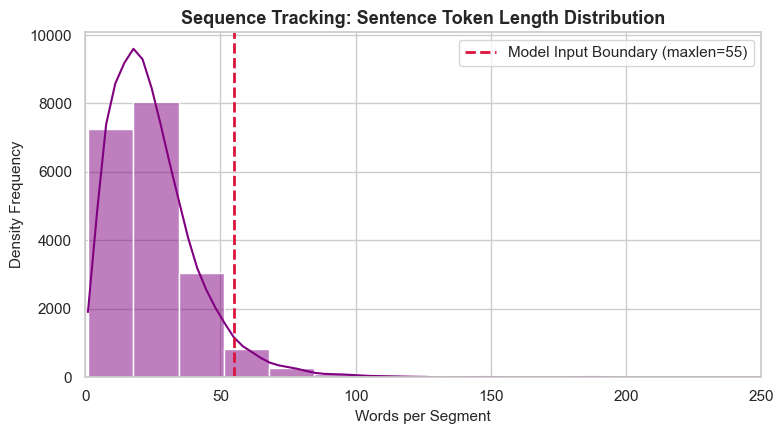

In [14]:
# Calculating the word counts per sentence using Spark functions
df_lengths = df_clean.withColumn("token_count", size(split(col("text"), "\\s+")))

# Pulling just the numerical lengths into a native Python list
print("Extracting length statistics for plotting...")
all_lengths_local = [row["token_count"] for row in df_lengths.select("token_count").collect()]

# Calculating the precise 95th percentile dynamic constraint variable
calculated_maxlen = int(np.percentile(all_lengths_local, 95))
print(f"Calculated 95th Percentile Dynamic Constraint: {calculated_maxlen}")

# Building and forcing display the custom assignment graph on screen
plt.clf()
plt.close('all')
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 4.5))

sns.histplot(all_lengths_local, bins=40, color="purple", kde=True)
plt.axvline(x=calculated_maxlen, color="crimson", linestyle="--", linewidth=2, 
            label=f"Model Input Boundary (maxlen={calculated_maxlen})")

plt.title("Sequence Tracking: Sentence Token Length Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Words per Segment", fontsize=11)
plt.ylabel("Density Frequency", fontsize=11)
plt.xlim(0, 250)  
plt.legend()
plt.tight_layout()

plt.show()


In [15]:
# FEATURE ENGINEERING & HANDLING TRAPS (DIRECT TO NATIVE LISTS WITH FILTER)

# Collecting Spark data columns
spark_records = df_eda.select("processed_text", "author").collect()

# Creating a clean temporary dictionary to count and filter out stray corrupted classes
from collections import Counter
raw_texts = [row["processed_text"] for row in spark_records if row["processed_text"] and row["author"]]
raw_authors = [row["author"] for row in spark_records if row["processed_text"] and row["author"]]

author_counts = Counter(raw_authors)

# Keeping the only texts and authors belonging to real classes with at least 10 entries
all_texts = []
all_authors = []
for t, a in zip(raw_texts, raw_authors):
    if author_counts[a] >= 10: 
        all_texts.append(t)
        all_authors.append(a)

# Mapping target author strings to multi-class index labels
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(all_authors)
num_classes = len(label_encoder.classes_)

print(f"Data cleaned successfully! Verified real authors found for training: {list(label_encoder.classes_)}")

# TRAP 1 FIX: Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    all_texts,
    encoded_labels,
    test_size=0.20,
    stratify=encoded_labels,  
    random_state=42

)

# TRAP 2 & 3 FIX: Vocabulary Hard-Cap (20,000) & OOV Mitigation Token
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# TRAP 4 FIX: Dynamic Sequence Padding Capped at 150 Tokens
MAX_SEQUENCE_LENGTH = 150
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

Data cleaned successfully! Verified real authors found for training: [' then', '"" I said', '"" he said', '"" said I', '"" said he', 'EAP', 'HPL', 'MWS']


In [16]:
# DEEP LEARNING MODEL ARCHITECTURE PLAN (KERAS)

model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH),
    SpatialDropout1D(0.4),
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=False)),
    Dense(num_classes, activation='softmax')
])

C:\Users\User\anaconda3\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
# ROBUST TRAINING & OPTIMIZATION STRATEGY

def lr_scheduler_engine(epoch):
    initial_learning_rate = 0.001
    decay_factor = 0.5
    drop_every_x_epochs = 4.0
    return initial_learning_rate * (decay_factor ** np.floor((1 + epoch) / drop_every_x_epochs))

lr_callback = LearningRateScheduler(lr_scheduler_engine)

early_stop_callback = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True,
    verbose=1
)

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

# Running training loops
print("\n--- Starting Neural Architecture Optimization Loop ---")
history = model.fit(
    X_train_padded, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_padded, y_test),
    callbacks=[early_stop_callback, lr_callback],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


--- Starting Neural Architecture Optimization Loop ---
Epoch 1/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.4140 - loss: 1.2487 - val_accuracy: 0.7072 - val_loss: 0.7341 - learning_rate: 0.0010
Epoch 2/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.7561 - loss: 0.6354 - val_accuracy: 0.7961 - val_loss: 0.5309 - learning_rate: 0.0010
Epoch 3/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 295s 1s/step - accuracy: 0.8622 - loss: 0.3843 - val_accuracy: 0.8190 - val_loss: 0.5079 - learning_rate: 0.0010
Epoch 4/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.9179 - loss: 0.2516 - val_accuracy: 0.8220 - val_loss: 0.5360 - learning_rate: 5.0000e-04
Epoch 5/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.9348 - loss: 0.2006 - val_accuracy: 0.8198 - val_loss: 0.5777 - learning_rate: 5.0000e-04
Epoch 6/15
227/227 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9446 - loss: 0.1732 - val_accuracy: 0.8171 - val_loss: 0.6179 - learning_rate: 5.0000e-04
Epoch 6: early

In [18]:
# MULTI-DIMENSIONAL EVALUATION FRAMEWORK

y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n=== 6. EVALUATION FRAMEWORK METRICS REPORT ===")
author_names = [str(name) for name in label_encoder.classes_]
print(classification_report(y_test, y_pred, target_names=author_names))

114/114 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step

=== 6. EVALUATION FRAMEWORK METRICS REPORT ===
              precision    recall  f1-score   support

        then       0.00      0.00      0.00         3
   "" I said       0.00      0.00      0.00         4
  "" he said       0.00      0.00      0.00         6
   "" said I       0.00      0.00      0.00         4
  "" said he       0.00      0.00      0.00         3
         EAP       0.81      0.83      0.82      1409
         HPL       0.82      0.84      0.83      1090
         MWS       0.83      0.80      0.81      1111

    accuracy                           0.82      3630
   macro avg       0.31      0.31      0.31      3630
weighted avg       0.81      0.82      0.82      3630



C:\Users\User\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\User\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [23]:

# FORCE LAYER IMPORTS TO FIX NAMEERROR

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, Bidirectional


# PHASE 1: THE BASELINE MODEL

print("--- Training Phase 1: Simple Baseline Model ---")

baseline_model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH),
   
    Dropout(0.2),
    
    LSTM(64, return_sequences=False),
    Dense(num_classes, activation='softmax')
])

baseline_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training baseline model 
baseline_history = baseline_model.fit(
    X_train_padded, y_train, 
    epochs=3, 
    batch_size=64, 
    validation_data=(X_test_padded, y_test), 
    verbose=1
)

# Evaluating Baseline
y_pred_base = np.argmax(baseline_model.predict(X_test_padded), axis=1)
print("\n=== BASELINE MODEL REPORT ===")
print(classification_report(y_test, y_pred_base, target_names=author_names, zero_division=0))



# PHASE 2: THE RETRAINED OPTIMIZED MODEL 

print("\n" + "="*60)
print("--- Training Phase 2: Retraining with Optimized Strategy ---")
print("="*60)

optimized_model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH),
    # Advanced Regularisation - Drops entire word channels to kill memorisation loops
    SpatialDropout1D(0.4),
    # Dual-Context Scan: Processes text forwards and backwards simultaneously
    Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3, return_sequences=False)),
    Dense(num_classes, activation='softmax')
])

optimized_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Training optimised model 
optimized_history = optimized_model.fit(
    X_train_padded, y_train, 
    epochs=6,  
    batch_size=64, 
    validation_data=(X_test_padded, y_test), 
    callbacks=[early_stop_callback, lr_callback], 
    verbose=1
)

# Evaluating Optimised Retrained Model
y_pred_opt = np.argmax(optimized_model.predict(X_test_padded), axis=1)
print("\n=== OPTIMIZED RETRAINED MODEL REPORT ===")
print(classification_report(y_test, y_pred_opt, target_names=author_names, zero_division=0))


--- Training Phase 1: Simple Baseline Model ---
Epoch 1/3


C:\Users\User\anaconda3\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


227/227 ━━━━━━━━━━━━━━━━━━━━ 61s 180ms/step - accuracy: 0.3738 - loss: 1.2652 - val_accuracy: 0.3061 - val_loss: 1.1366
Epoch 2/3
227/227 ━━━━━━━━━━━━━━━━━━━━ 40s 175ms/step - accuracy: 0.3624 - loss: 1.1334 - val_accuracy: 0.3061 - val_loss: 1.1346
Epoch 3/3
227/227 ━━━━━━━━━━━━━━━━━━━━ 39s 171ms/step - accuracy: 0.3619 - loss: 1.1329 - val_accuracy: 0.3884 - val_loss: 1.1332
114/114 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step

=== BASELINE MODEL REPORT ===
              precision    recall  f1-score   support

        then       0.00      0.00      0.00         3
   "" I said       0.00      0.00      0.00         4
  "" he said       0.00      0.00      0.00         6
   "" said I       0.00      0.00      0.00         4
  "" said he       0.00      0.00      0.00         3
         EAP       0.39      1.00      0.56      1409
         HPL       0.00      0.00      0.00      1090
         MWS       0.57      0.00      0.01      1111

    accuracy                           0.39      3630
   ma

C:\Users\User\anaconda3\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


227/227 ━━━━━━━━━━━━━━━━━━━━ 291s 1s/step - accuracy: 0.4104 - loss: 1.2556 - val_accuracy: 0.6981 - val_loss: 0.7443 - learning_rate: 0.0010
Epoch 2/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.7524 - loss: 0.6385 - val_accuracy: 0.7961 - val_loss: 0.5399 - learning_rate: 0.0010
Epoch 3/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.8684 - loss: 0.3733 - val_accuracy: 0.8160 - val_loss: 0.5248 - learning_rate: 0.0010
Epoch 4/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.9150 - loss: 0.2557 - val_accuracy: 0.8289 - val_loss: 0.5136 - learning_rate: 5.0000e-04
Epoch 5/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9368 - loss: 0.2011 - val_accuracy: 0.8242 - val_loss: 0.5455 - learning_rate: 5.0000e-04
Epoch 6/6
227/227 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9470 - loss: 0.1699 - val_accuracy: 0.8204 - val_loss: 0.5908 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 4.
114/114 ━━━━━━━━━━━━━━━━━━━